# Cocoa Pod Disease Detection (YOLOv11) — Source Code

**Author:** K. M. Muyisa


In [ ]:
# Mount Google Drive (Google Colab) — the cocoa dataset lives in your Drive.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Not on Colab (or already mounted):', e)

import os
os.makedirs('/content/drive/MyDrive/cocoa_outputs', exist_ok=True)
# Edit these two paths to match your Drive layout:
COCOA_ROOT = '/content/drive/MyDrive/cocoa_dataset/cocoa_diseases'
OUTPUT_DIR = '/content/drive/MyDrive/cocoa_outputs'


# Import Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os


from sklearn.model_selection import train_test_split

!pip install ultralytics

from ultralytics import YOLO

from IPython.display import Image, display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

**Available Classes**

In [2]:

import json

with open("/content/drive/MyDrive/cocoa_dataset/cocoa_diseases/notes.json", "r") as f:
    temp = json.load(f)

temp['categories']

[{'id': 0, 'name': 'Health'},
 {'id': 1, 'name': 'carmenta foraseminis'},
 {'id': 2, 'name': 'moniliophthora perniciosa'},
 {'id': 3, 'name': 'moniliophthora roreri'},
 {'id': 4, 'name': 'phytophthora palmivora'}]

## Train / Validation Dataset Creation

In [3]:
base_dir = "/content/drive/MyDrive/cocoa_dataset/cocoa_diseases/"

_images_path = os.path.join(base_dir, "images")
_labels_path = os.path.join(base_dir, "labels")

_paths,_labels = [],[]
for el in os.listdir(_labels_path):
    _path = os.path.join(_labels_path, el)
    with open(_path, "r") as f:
        label,*_ = f.readline()
    
    _paths.append(el.strip(".txt"))
    _labels.append(int(label))

In [4]:
# Generate Metadata train/val split
metadata_df = pd.DataFrame({"name":_paths,"class":_labels})

y = metadata_df.pop("class")
X = metadata_df

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=2025)

pd.concat([y_train.value_counts(normalize=True).rename("train"), 
           y_val.value_counts(normalize=True).rename("val")], axis=1)

,train,val
class,,
0,0.683534,0.661316
4,0.107229,0.101124
3,0.105622,0.141252
1,0.072691,0.065811
2,0.030924,0.030498


**Due to class imabalance**, Train and Validation Dataset should have the same class proportion. 

In [5]:
# Generate train and validation .txt
# Save split files into /content/drive/MyDrive/cocoa_outputs/
def save_list(filename, file_list):

    file_list = (file_list["name"]+".jpg").apply(lambda t: os.path.join(_images_path, t)).to_list()
    with open(filename, "w") as f:
        f.write("\n".join(file_list))
        

save_list(os.path.join(OUTPUT_DIR, "train.txt"), X_train)
save_list(os.path.join(OUTPUT_DIR, "val.txt"),   X_val)

**Yolo** automatically assumes that the corresponding **labels** are in a parallel directory called `labels/` with the same structure as `images/`.

In [6]:
%%writefile /content/drive/MyDrive/cocoa_outputs/dataset.yaml

train: /content/drive/MyDrive/cocoa_outputs/train.txt
val: /content/drive/MyDrive/cocoa_outputs/val.txt

nc: 5
names:
  0: Health
  1: carmenta foraseminis
  2: moniliophthora perniciosa
  3: moniliophthora roreri
  4: phytophthora palmivora


Writing dataset.yaml


# Model Training

In [7]:
# Load a model
model = YOLO("yolo11n.pt")  # load a pretrained model

# Train the model
results = model.train(data="/content/drive/MyDrive/cocoa_outputs/dataset.yaml", epochs=25, imgsz=640)

Ultralytics 8.3.199 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        623        664      0.756      0.861      0.847      0.775
                Health        414        430      0.924      0.967      0.982      0.897
  carmenta foraseminis         41         44      0.805      0.705      0.774      0.709
moniliophthora perniciosa         19         19      0.621          1      0.834      0.784
 moniliophthora roreri         88         99      0.786      0.879      0.878      0.772
phytophthora palmivora         63         72      0.644      0.753       0.77      0.715
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/train


## Model Inference

In [8]:
# Load the best trained model
model = YOLO("/content/drive/MyDrive/cocoa_outputs/runs/detect/train/weights/best.pt")

#### From Dataset

In [9]:
results = model.predict(source="/content/drive/MyDrive/cocoa_dataset/cocoa_diseases/images/00c23d10-f901-4dc0-9c6c-5aab92db10c4.jpg", 
                        save=True,
                        imgsz=640, conf=0.25)


image 1/1 /kaggle/input/cocoa-diseases/cocoa_diseases/images/00c23d10-f901-4dc0-9c6c-5aab92db10c4.jpg: 640x480 1 Health, 42.6ms
Speed: 2.2ms preprocess, 42.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /kaggle/working/runs/detect/predict


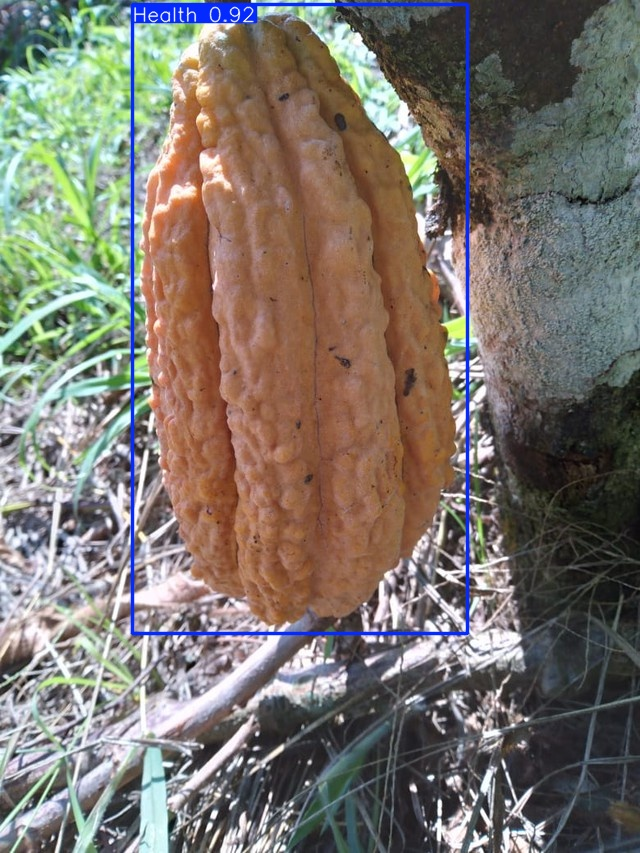

In [10]:
# Show one of the output images
display(Image(filename="/content/drive/MyDrive/cocoa_outputs/runs/detect/predict/00c23d10-f901-4dc0-9c6c-5aab92db10c4.jpg"))

#### From Internet

In [11]:
import requests
from pathlib import Path

# Download an image from the web
url = "https://progresacaribe.info/wp-content/uploads/2022/08/Enfermdades_destacada.webp"
img_path = Path("internet_image.jpg")

response = requests.get(url)
img_path.write_bytes(response.content)

# Run inference
results = model.predict(source=str(img_path), save=True, imgsz=640, conf=0.25)


image 1/1 /kaggle/working/internet_image.jpg: 448x640 1 phytophthora palmivora, 43.2ms
Speed: 2.3ms preprocess, 43.2ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/predict


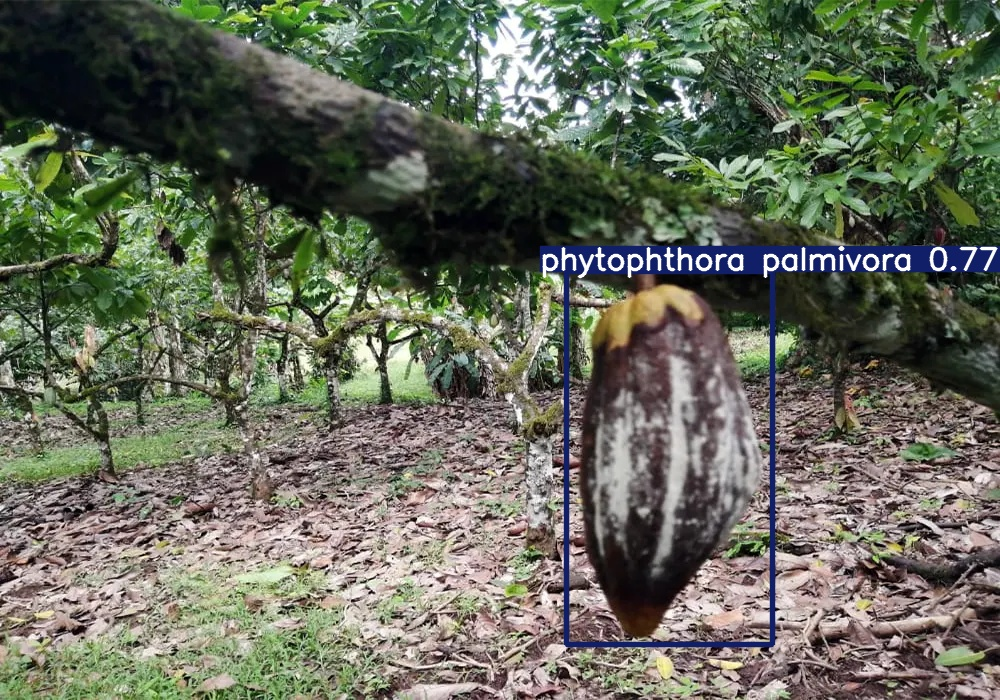

In [12]:
display(Image(filename="/content/drive/MyDrive/cocoa_outputs/runs/detect/predict/internet_image.jpg"))